# Практическая работа № 4. Регрессионная модель

Уровень C.

Датасет: объявления о продаже подержанных автомобилей.
Целевая переменная: price — запрашиваемая цена в долларах США.

Цель: реализовать линейную регрессию с градиентным спуском
на NumPy и сравнить её с LinearRegression из scikit-learn.

Предобработка основана на Pipeline из ПР-3.
Данные разделяются до вычисления обучаемых статистик.
Предобработка обучается только на train.

In [10]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split

print("Python:", sys.version.split()[0])
print("Интерпретатор:", sys.executable)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.10
Интерпретатор: c:\Users\lulu\Documents\Projects\ml_course\ml-social-media-sleep\.venv\Scripts\python.exe
NumPy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1


In [11]:
candidate_paths = [
    Path("data/raw/used_cars.csv"),
    Path("../data/raw/used_cars.csv"),
    Path("ml-social-media-sleep/data/raw/used_cars.csv"),
]

DATA_PATH = next(
    (path for path in candidate_paths if path.is_file()),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/raw/used_cars.csv")

df = pd.read_csv(DATA_PATH)

print("Размер:", df.shape)
display(df.head())

Размер: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [12]:
FEATURES = [
    "brand",
    "model_year",
    "milage",
    "fuel_type",
    "accident",
    "clean_title",
]

X = df[FEATURES].copy()

price_text = (
    df["price"]
    .astype("string")
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

y = pd.to_numeric(price_text, errors="coerce").astype(float)

print("Нераспознанных цен:", y.isna().sum())
print("Минимальная цена:", y.min())
print("Максимальная цена:", y.max())

assert np.isfinite(y.to_numpy()).all(), "Есть некорректные цены"
assert (y > 0).all(), "Есть неположительные цены"
assert "price" not in X.columns

display(pd.DataFrame({
    "Исходная цена": df["price"].head(),
    "Цена числом, USD": y.head(),
}))

Нераспознанных цен: 0
Минимальная цена: 2000.0
Максимальная цена: 2954083.0


,Исходная цена,"Цена числом, USD"
0,"$10,300",10300.0
1,"$38,005",38005.0
2,"$54,598",54598.0
3,"$15,500",15500.0
4,"$34,999",34999.0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Цены train:", y_train.shape)
print("Цены test:", y_test.shape)

assert set(X_train.index).isdisjoint(X_test.index)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

Train: (3207, 6)
Test: (802, 6)
Цены train: (3207,)
Цены test: (802,)


## Подготовка данных

Загружено 4009 объявлений с 12 исходными столбцами.
Целевая переменная price преобразована из строк в числовые цены USD.
После преобразования нераспознанных цен нет.

Для продолжения выбраны те же шесть входных признаков, что в ПР-3.
Данные разделены на 3207 обучающих и 802 тестовых наблюдения
с random_state=42.

Медианы, параметры масштабирования и категории кодировщика
на этом этапе ещё не вычислялись.

## Предобработка из ПР-3

Используем собственный BrandMileageTransformer и Pipeline из ПР-3.

Обучаем предобработку только на train.
К test применяем уже обученный Pipeline.

После обработки переводим признаки в массивы NumPy
и добавляем столбец единиц для свободного члена регрессии.

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

In [15]:
class BrandMileageTransformer(TransformerMixin, BaseEstimator):


    @staticmethod
    def _parse_milage(series):
        text = (
            series.astype("string")
            .str.replace(",", "", regex=False)
            .str.replace("mi.", "", regex=False)
            .str.strip()
        )

        values = pd.to_numeric(text, errors="coerce").astype(float)

        return values.where(
            np.isfinite(values) & (values >= 0),
            np.nan,
        )

    @staticmethod
    def _brand_keys(series):
        return (
            series.astype("string")
            .str.strip()
            .fillna("__UNKNOWN_BRAND__")
        )

    def fit(self, X, y=None):
        milage = self._parse_milage(X["milage"])
        brands = self._brand_keys(X["brand"])

        global_median = milage.median()

        if pd.isna(global_median):
            raise ValueError(
                "В train нет корректного пробега для расчёта медианы."
            )

        statistics = pd.DataFrame({
            "brand": brands,
            "milage": milage,
        })

        self.global_median_ = float(global_median)

        self.brand_medians_ = (
            statistics.groupby("brand")["milage"]
            .median()
            .dropna()
        )

        return self

    def transform(self, X):
        check_is_fitted(
            self,
            ["global_median_", "brand_medians_"],
        )

        result = X.copy()

        milage = self._parse_milage(result["milage"])
        brands = self._brand_keys(result["brand"])

        reference = brands.map(self.brand_medians_)

        reference = reference.fillna(self.global_median_)

        result["milage"] = milage

        result["relative_milage"] = (
            (milage + 1) / (reference + 1)
        )

        return result

In [16]:
numeric_features = [
    "model_year",
    "milage",
    "relative_milage",
]

categorical_features = [
    "brand",
    "fuel_type",
    "accident",
    "clean_title",
]

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="неизвестно",
        ),
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        ),
    ),
])

columns = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

pipeline = Pipeline([
    ("brand_milage", BrandMileageTransformer()),
    ("columns", columns),
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('brand_milage', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, def

In [17]:
X_train_ready = pipeline.fit_transform(X_train)
X_test_ready = pipeline.transform(X_test)

print("Train после обработки:", X_train_ready.shape)
print("Test после обработки:", X_test_ready.shape)

assert X_train_ready.shape[1] == X_test_ready.shape[1]

Train после обработки: (3207, 72)
Test после обработки: (802, 72)


In [18]:
def to_dense_float(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()

    return np.asarray(matrix, dtype=np.float64)


X_train_np = to_dense_float(X_train_ready)
X_test_np = to_dense_float(X_test_ready)

y_train_np = y_train.to_numpy(dtype=np.float64)
y_test_np = y_test.to_numpy(dtype=np.float64)

print("Признаки train:", X_train_np.shape)
print("Цены train:", y_train_np.shape)
print("Тип массива:", type(X_train_np))
print("Первые пять цен:", y_train_np[:5])

assert np.isfinite(X_train_np).all()
assert np.isfinite(X_test_np).all()
assert np.isfinite(y_train_np).all()
assert np.isfinite(y_test_np).all()

Признаки train: (3207, 72)
Цены train: (3207,)
Тип массива: <class 'numpy.ndarray'>
Первые пять цен: [30510. 82000. 49999. 30000. 12000.]


In [19]:
X_train_bias = np.column_stack([
    np.ones(X_train_np.shape[0]),
    X_train_np,
])

X_test_bias = np.column_stack([
    np.ones(X_test_np.shape[0]),
    X_test_np,
])

print("Train со свободным членом:", X_train_bias.shape)
print("Test со свободным членом:", X_test_bias.shape)
print("Первые пять значений первого столбца:", X_train_bias[:5, 0])

assert np.all(X_train_bias[:, 0] == 1)
assert np.all(X_test_bias[:, 0] == 1)

Train со свободным членом: (3207, 73)
Test со свободным членом: (802, 73)
Первые пять значений первого столбца: [1. 1. 1. 1. 1.]


Предобработка из ПР-3 обучена только на train.
Для test использован transform без повторного обучения.

Получены 72 обработанных признака.
Массивы признаков не содержат пропусков и бесконечных значений.

Для собственной линейной регрессии добавлен столбец единиц:
теперь обучающая матрица имеет размер 3207 × 73.
Первый параметр модели будет свободным членом.

## Собственная функция потерь MSE и её градиент

Линейная регрессия вычисляет предсказания как X @ weights.
Первый столбец X заполнен единицами, поэтому weights[0]
является свободным членом.

MSE — среднее квадратов ошибок предсказания.
При цене в USD единица измерения MSE — USD².

Градиент показывает, как изменяется MSE при изменении
каждого параметра модели. Для уменьшения ошибки параметры
будут обновляться в направлении, противоположном градиенту.

In [20]:
def mse_loss(X, y, weights):
    predictions = X @ weights
    errors = predictions - y
    return np.mean(errors ** 2)

In [21]:
def mse_gradient(X, y, weights):
    n = X.shape[0]
    predictions = X @ weights
    errors = predictions - y

    return (2 / n) * (X.T @ errors)

In [22]:
X_small = np.array([
    [1.0, 0.0],
    [1.0, 1.0],
    [1.0, 2.0],
])

y_small = np.array([1.0, 3.0, 5.0])

weights_small = np.zeros(2)

print("Предсказания:", X_small @ weights_small)
print("MSE:", mse_loss(X_small, y_small, weights_small))
print("Градиент:", mse_gradient(X_small, y_small, weights_small))

np.testing.assert_allclose(
    mse_loss(X_small, y_small, weights_small),
    35 / 3,
)

np.testing.assert_allclose(
    mse_gradient(X_small, y_small, weights_small),
    [-6.0, -26 / 3],
)

perfect_weights = np.array([1.0, 2.0])

np.testing.assert_allclose(
    mse_loss(X_small, y_small, perfect_weights),
    0.0,
)

np.testing.assert_allclose(
    mse_gradient(X_small, y_small, perfect_weights),
    [0.0, 0.0],
)

print("Проверки MSE и градиента пройдены.")

Предсказания: [0. 0. 0.]
MSE: 11.666666666666666
Градиент: [-6.         -8.66666667]
Проверки MSE и градиента пройдены.


In [23]:
weights_zero = np.zeros(X_train_bias.shape[1])

initial_loss = mse_loss(
    X_train_bias,
    y_train_np,
    weights_zero,
)

initial_gradient = mse_gradient(
    X_train_bias,
    y_train_np,
    weights_zero,
)

print("Количество параметров:", weights_zero.shape[0])
print(f"Начальный MSE: {initial_loss:,.2f} USD²")
print("Размер градиента:", initial_gradient.shape)
print("Первые пять компонентов градиента:")
print(initial_gradient[:5])

assert initial_gradient.shape == weights_zero.shape
assert np.isfinite(initial_loss)
assert np.isfinite(initial_gradient).all()

Количество параметров: 73
Начальный MSE: 4,480,915,805.87 USD²
Размер градиента: (73,)
Первые пять компонентов градиента:
[-86251.51356408 -36171.60624573  45256.43767439  32928.34643517
   -927.87652011]


Функция MSE и её аналитический градиент реализованы на NumPy
без готовых функций потерь и автоматического дифференцирования.

На маленьком примере результаты совпали с ручным расчётом.
Для параметров, точно описывающих пример, MSE и градиент равны нулю.

На обучающих автомобильных данных проверены начальная ошибка
и размер градиента: по одному компоненту на каждый из 73 параметров.
Обучение модели пока не выполнялось.

## Градиентный спуск

На каждой итерации вычисляем градиент MSE по всей обучающей выборке
и обновляем параметры:

weights = weights - learning_rate * gradient

learning_rate — скорость обучения, определяющая размер шага.
n_iter — заданное количество обновлений параметров.

Сравниваем три скорости обучения при одинаковом количестве итераций
и одинаковых начальных параметрах. Используем только train.

In [24]:
def gradient_descent(X, y, learning_rate=0.01, n_iter=5000):
    if learning_rate <= 0:
        raise ValueError("learning_rate должен быть положительным")

    if n_iter <= 0:
        raise ValueError("n_iter должен быть положительным")

    weights = np.zeros(X.shape[1], dtype=np.float64)

    loss_history = [mse_loss(X, y, weights)]

    for iteration in range(n_iter):
        with np.errstate(over="ignore", invalid="ignore"):
            gradient = mse_gradient(X, y, weights)
            new_weights = weights - learning_rate * gradient
            new_loss = mse_loss(X, y, new_weights)

        if (
            not np.isfinite(new_weights).all()
            or not np.isfinite(new_loss)
        ):
            raise FloatingPointError(
                f"Некорректные значения на итерации {iteration + 1}. "
                "Проверь масштаб признаков и уменьши learning_rate."
            )

        weights = new_weights
        loss_history.append(new_loss)

    return weights, np.asarray(loss_history)

In [25]:
small_weights, small_history = gradient_descent(
    X_small,
    y_small,
    learning_rate=0.1,
    n_iter=1000,
)

print("Найденные параметры:", small_weights)
print("Начальный MSE:", small_history[0])
print("Конечный MSE:", small_history[-1])

np.testing.assert_allclose(
    small_weights,
    [1.0, 2.0],
    atol=1e-5,
)

assert small_history[-1] < small_history[0]

print("Проверка градиентного спуска пройдена.")

Найденные параметры: [1. 2.]
Начальный MSE: 11.666666666666666
Конечный MSE: 1.6598948214025456e-30
Проверка градиентного спуска пройдена.


In [26]:
learning_rates = [0.001, 0.01, 0.1]
n_iter = 5000

gd_runs = {}
summary_rows = []

for learning_rate in learning_rates:
    print(f"Обучение: learning_rate={learning_rate}")

    weights, history = gradient_descent(
        X_train_bias,
        y_train_np,
        learning_rate=learning_rate,
        n_iter=n_iter,
    )

    gd_runs[learning_rate] = {
        "weights": weights,
        "history": history,
    }

    summary_rows.append({
        "learning_rate": learning_rate,
        "iterations": len(history) - 1,
        "initial_train_MSE": history[0],
        "final_train_MSE": history[-1],
        "decrease_percent": (
            100 * (history[0] - history[-1]) / history[0]
        ),
    })

gd_summary = pd.DataFrame(summary_rows)
display(gd_summary.round(3))

Обучение: learning_rate=0.001
Обучение: learning_rate=0.01
Обучение: learning_rate=0.1


,learning_rate,iterations,initial_train_MSE,final_train_MSE,decrease_percent
0,0.001,5000,4.480916e+09,1.919584e+09,57.161
1,0.010,5000,4.480916e+09,1.424221e+09,68.216
2,0.100,5000,4.480916e+09,9.195640e+08,79.478


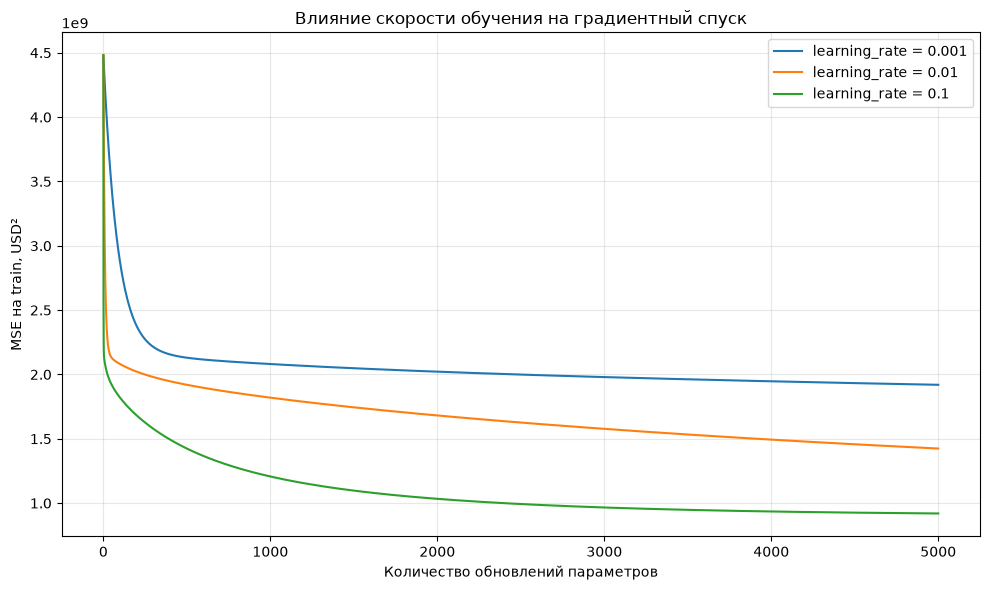

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for learning_rate, run in gd_runs.items():
    history = run["history"]

    ax.plot(
        np.arange(len(history)),
        history,
        label=f"learning_rate = {learning_rate}",
    )

ax.set_xlabel("Количество обновлений параметров")
ax.set_ylabel("MSE на train, USD²")
ax.set_title("Влияние скорости обучения на градиентный спуск")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

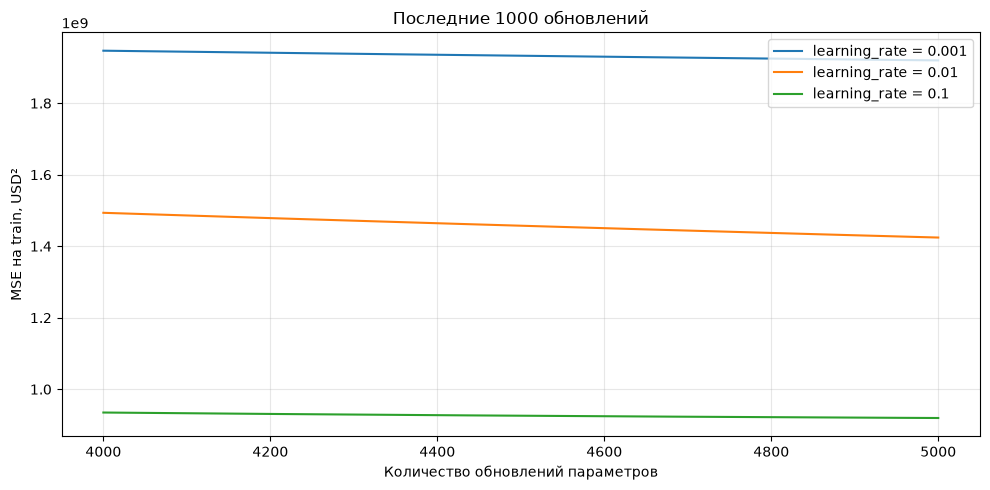

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

for learning_rate, run in gd_runs.items():
    history = run["history"]
    start = max(0, len(history) - 1001)

    ax.plot(
        np.arange(start, len(history)),
        history[start:],
        label=f"learning_rate = {learning_rate}",
    )

ax.set_xlabel("Количество обновлений параметров")
ax.set_ylabel("MSE на train, USD²")
ax.set_title("Последние 1000 обновлений")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
best_lr = min(
    gd_runs,
    key=lambda lr: gd_runs[lr]["history"][-1],
)

weights_gd = gd_runs[best_lr]["weights"].copy()
history_gd = gd_runs[best_lr]["history"].copy()

print("Выбранная скорость:", best_lr)
print(f"Конечный train MSE: {history_gd[-1]:,.2f} USD²")
print("Количество параметров:", weights_gd.shape[0])

Выбранная скорость: 0.1
Конечный train MSE: 919,563,964.06 USD²
Количество параметров: 73


## Результат исследования скорости обучения

Реализован собственный градиентный спуск на NumPy.
На маленьком примере получены параметры, близкие к [1, 2].

На автомобильных данных исследованы скорости [указать значения].
Каждый запуск начинался с нулевых параметров
и выполнял 5000 обновлений по всей обучающей выборке.

Самое быстрое снижение MSE наблюдалось при [значение].
При [значение] обучение шло медленнее.
[Указать, наблюдались ли рост ошибки или колебания.]

Для дальнейшего сравнения выбрана скорость [значение]:
она дала минимальный конечный train MSE среди исследованных запусков.
Тестовая выборка при выборе скорости не использовалась.

## Сравнение собственной регрессии со scikit-learn

Обе модели используют одинаковую предобработку,
одинаковое разбиение и одинаковую матрицу признаков.

В матрицу уже добавлен столбец единиц для свободного члена.
Поэтому LinearRegression используется с fit_intercept=False.

Скорость обучения собственной модели выбрана по train.
Тестовая выборка используется для итоговой оценки качества.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

sklearn_model = LinearRegression(fit_intercept=False)

sklearn_model.fit(X_train_bias, y_train_np)

weights_sklearn = sklearn_model.coef_.copy()

print("Параметров собственной модели:", weights_gd.shape[0])
print("Параметров sklearn:", weights_sklearn.shape[0])

print(
    "Train MSE собственной модели:",
    mse_loss(X_train_bias, y_train_np, weights_gd),
)

print(
    "Train MSE sklearn:",
    mse_loss(X_train_bias, y_train_np, weights_sklearn),
)

Параметров собственной модели: 73
Параметров sklearn: 73
Train MSE собственной модели: 919563964.0584103
Train MSE sklearn: 901249733.3733628


In [31]:
feature_names = (
    pipeline.named_steps["columns"]
    .get_feature_names_out()
    .tolist()
)

parameter_names = ["Свободный член"] + feature_names

coefficients = pd.DataFrame({
    "parameter": parameter_names,
    "NumPy_GD": weights_gd,
    "sklearn": weights_sklearn,
})

coefficients["absolute_difference"] = (
    coefficients["NumPy_GD"] - coefficients["sklearn"]
).abs()

display(
    coefficients
    .sort_values("absolute_difference", ascending=False)
    .head(15)
    .round(2)
)

gd_train_mse = mse_loss(
    X_train_bias, y_train_np, weights_gd
)

sklearn_train_mse = mse_loss(
    X_train_bias, y_train_np, weights_sklearn
)

print(
    "Разница train MSE, % относительно sklearn:",
    100 * (gd_train_mse - sklearn_train_mse)
    / sklearn_train_mse,
)

,parameter,NumPy_GD,sklearn,absolute_difference
49,categorical__brand_Rolls-Royce,358645.16,434222.36,75577.20
54,categorical__brand_Suzuki,-11373.40,-59935.25,48561.85
50,categorical__brand_Saab,-9333.71,-53514.85,44181.13
38,categorical__brand_McLaren,132575.59,169030.72,36455.13
59,categorical__brand_smart,-10791.02,-45690.77,34899.75
52,categorical__brand_Scion,-36316.43,-66584.58,30268.14
33,categorical__brand_Lucid,13777.94,43823.61,30045.67
40,categorical__brand_Mercury,-4270.38,-30650.92,26380.54
36,categorical__brand_Maybach,7104.81,29205.13,22100.32
51,categorical__brand_Saturn,-29973.11,-48746.96,18773.86


Разница train MSE, % относительно sklearn: 2.0320927715004857


In [ ]:
pred_train_gd = X_train_bias @ weights_gd
pred_test_gd = X_test_bias @ weights_gd

pred_train_sklearn = sklearn_model.predict(X_train_bias)
pred_test_sklearn = sklearn_model.predict(X_test_bias)

mean_train_price = y_train_np.mean()

pred_train_mean = np.full(
    y_train_np.shape,
    mean_train_price,
)

pred_test_mean = np.full(
    y_test_np.shape,
    mean_train_price,
)


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE_USD": mean_absolute_error(y_true, y_pred),
        "MSE_USD2": mse,
        "RMSE_USD": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


predictions = {
    "NumPy GD": (pred_train_gd, pred_test_gd),
    "sklearn": (pred_train_sklearn, pred_test_sklearn),
    "Средняя цена train": (pred_train_mean, pred_test_mean),
}

metric_rows = []

for model_name, (pred_train, pred_test) in predictions.items():
    for split_name, y_true, y_pred in [
        ("train", y_train_np, pred_train),
        ("test", y_test_np, pred_test),
    ]:
        metric_rows.append({
            "model": model_name,
            "split": split_name,
            **regression_metrics(y_true, y_pred),
        })

metrics_table = pd.DataFrame(metric_rows)

display(metrics_table.round(3))

,model,split,MAE_USD,MSE_USD2,RMSE_USD,R2
0,NumPy GD,train,16336.897,9.195640e+08,30324.313,0.649
1,NumPy GD,test,24884.724,1.898541e+10,137787.543,0.071
2,sklearn,train,16125.010,9.012497e+08,30020.822,0.656
3,sklearn,test,24705.084,1.901635e+10,137899.782,0.070
4,Средняя цена train,train,27662.042,2.621085e+09,51196.532,0.000
5,Средняя цена train,test,35276.159,2.049048e+10,143144.978,-0.002


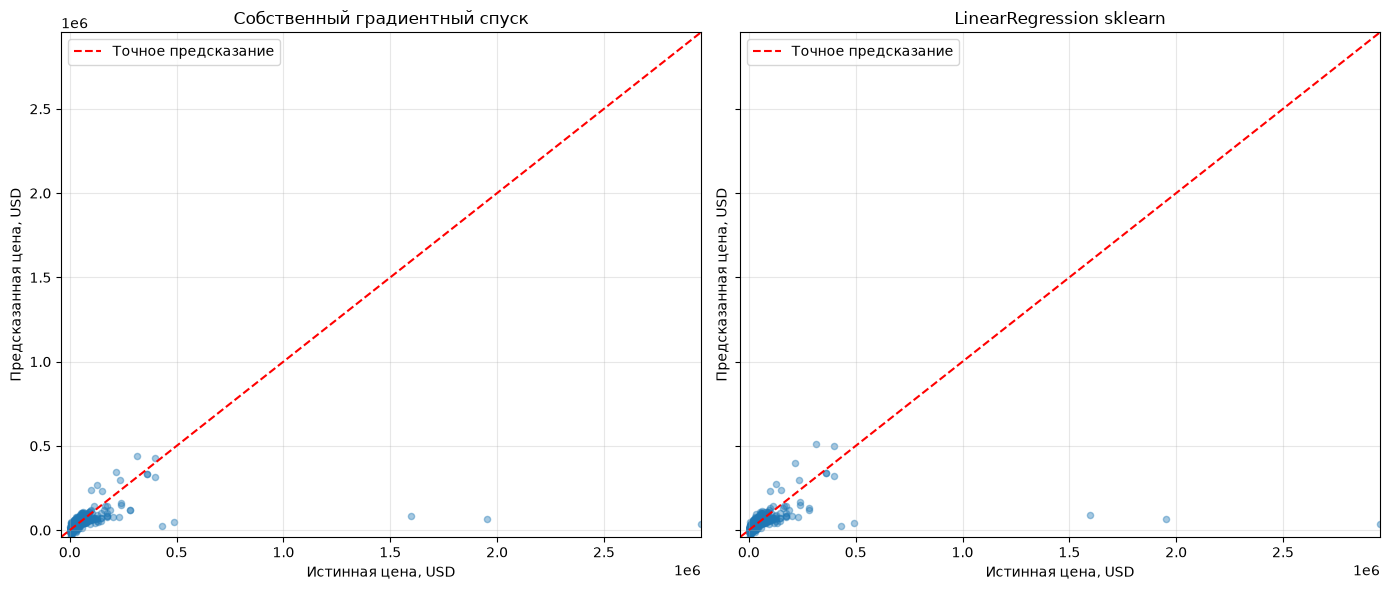

In [33]:
all_values = np.concatenate([
    y_test_np,
    pred_test_gd,
    pred_test_sklearn,
])

lower = all_values.min()
upper = all_values.max()

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharex=True,
    sharey=True,
)

for ax, name, prediction in [
    (axes[0], "Собственный градиентный спуск", pred_test_gd),
    (axes[1], "LinearRegression sklearn", pred_test_sklearn),
]:
    ax.scatter(
        y_test_np,
        prediction,
        alpha=0.4,
        s=20,
    )

    ax.plot(
        [lower, upper],
        [lower, upper],
        color="red",
        linestyle="--",
        label="Точное предсказание",
    )

    ax.set_title(name)
    ax.set_xlabel("Истинная цена, USD")
    ax.set_ylabel("Предсказанная цена, USD")
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Сравнение моделей

Собственная модель и LinearRegression обучены на одинаковых
признаках и одинаковой обучающей выборке.

Train MSE:
- собственная модель — [значение] USD²;
- sklearn — [значение] USD².

Коэффициенты [описать степень совпадения].
Различия могут быть связаны с конечным числом итераций
и неединственностью коэффициентов при полном one-hot кодировании.

На test собственная модель получила:
- MAE — [значение] USD: средний абсолютный промах цены;
- RMSE — [значение] USD: ошибка с усиленным вкладом крупных промахов;
- R² — [значение].

По сравнению с предсказанием средней цены train модель
[улучшила / не улучшила] тестовые MAE и RMSE.

На графике предсказаний видно [конкретное наблюдение].
Различие между MAE и RMSE составляет [описать],
что [согласуется / не согласуется] с наличием отдельных крупных ошибок.

In [34]:
error_analysis = X_test.copy()

error_analysis["true_price_USD"] = y_test_np
error_analysis["prediction_USD"] = pred_test_gd

error_analysis["error_USD"] = (
    pred_test_gd - y_test_np
)

error_analysis["squared_error"] = (
    error_analysis["error_USD"] ** 2
)

error_analysis["share_squared_error_percent"] = (
    100
    * error_analysis["squared_error"]
    / error_analysis["squared_error"].sum()
)

largest_errors = error_analysis.sort_values(
    "squared_error",
    ascending=False,
)

display(
    largest_errors[[
        "brand",
        "model_year",
        "true_price_USD",
        "prediction_USD",
        "error_USD",
        "share_squared_error_percent",
    ]]
    .head(5)
    .round(2)
)

print(
    "Доля трёх крупнейших ошибок, %:",
    largest_errors["share_squared_error_percent"]
    .head(3)
    .sum(),
)

print("Максимальная цена train:", y_train_np.max())
print("Максимальная цена test:", y_test_np.max())

,brand,model_year,true_price_USD,prediction_USD,error_USD,share_squared_error_percent
693,Maserati,2005,2954083.0,34217.36,-2919865.64,55.99
229,Bugatti,2011,1950995.0,64919.03,-1886075.97,23.36
3046,Porsche,2005,1599000.0,85654.57,-1513345.43,15.04
1061,Dodge,2017,489995.0,48075.40,-441919.60,1.28
203,Ford,2005,429998.0,26274.52,-403723.48,1.07


Доля трёх крупнейших ошибок, %: 94.39664018530715
Максимальная цена train: 749950.0
Максимальная цена test: 2954083.0


## Результат исследования скорости обучения

Реализован собственный градиентный спуск на NumPy.
На маленьком примере получены правильные параметры [1, 2].

Исследованы скорости обучения 0.001, 0.01 и 0.1.
Каждый запуск начинался с нулевых параметров
и выполнял 5000 обновлений по всей обучающей выборке.

Конечный train MSE:
- learning_rate=0.001 — примерно 1.920 млрд USD²;
- learning_rate=0.01 — примерно 1.424 млрд USD²;
- learning_rate=0.1 — примерно 919.564 млн USD².

За одинаковое число итераций скорость 0.1 дала
наименьшую обучающую ошибку среди исследованных значений.
Поэтому её параметры использованы для дальнейшего сравнения.
Test при выборе скорости не использовался.

Увеличение скорости не гарантирует улучшения:
слишком большой шаг может привести к росту ошибки и расходимости.
Полученные результаты относятся к выбранным данным
и исследованным скоростям.

## Сравнение моделей

Собственная модель и LinearRegression обучены на одинаковой
матрице признаков и одинаковой обучающей выборке.

Train MSE собственной модели составил 919 563 964.06 USD²,
а sklearn — 901 249 733.37 USD².
Обучающая ошибка собственной модели на 2.03% выше.
Таким образом, за 5000 итераций градиентный спуск приблизился
к решению sklearn, но не достиг такого же train MSE.

Коэффициенты не совпали полностью. Например, коэффициент
brand_Rolls-Royce составил примерно 358 645 у собственной модели
и 434 222 у sklearn.

Конечное число итераций влияет на различия коэффициентов.
Кроме того, полное one-hot кодирование вместе со свободным членом
допускает неединственные наборы параметров.
Поэтому коэффициенты рассматриваются вместе с метриками.

Коэффициенты числовых признаков относятся к масштабированным
значениям. Коэффициент марки не является полной ценой автомобиля:
предсказание складывается из свободного члена
и вкладов всех признаков.

На test собственная модель получила:
- MAE = 24 884.72 USD — средний абсолютный промах цены;
- RMSE = 137 787.54 USD — метрика в долларах,
  сильнее реагирующая на крупные ошибки;
- R² ≈ 0.071 — небольшое улучшение квадратичной ошибки
  относительно постоянного предсказания среднего test.

Sklearn получил MAE = 24 705.08 USD,
RMSE = 137 899.78 USD и R² ≈ 0.070.
Его MAE немного ниже, но RMSE немного выше.

Обе модели улучшили test MAE и RMSE по сравнению
с предсказанием средней цены train.
Однако качество нельзя назвать высоким:
тестовый R² низкий, а ошибки цены существенны.

## Анализ ошибок и ограничения

На графике предсказаний обе модели сильно недооценивают
несколько самых дорогих автомобилей.
Из-за общего диапазона цен основная масса точек
расположена в нижней левой части графика.

Три объявления с крупнейшими ошибками дают примерно 94.4%
суммы квадратов ошибок собственной модели на test.
Это объясняет, почему RMSE значительно превышает MAE.

Максимальная цена train равна 749 950 USD,
а максимальная цена test — 2 954 083 USD.
Тестовая выборка содержит автомобили значительно дороже
максимума обучающей выборки.

Экстремальная цена сама по себе не доказывает ошибку данных.
Такие объявления требуют проверки источника.
При текущей оценке они сохранены.

Ограничения:
- используются только шесть исходных признаков;
- название модели автомобиля и характеристики двигателя
  не включены в текущий набор;
- линейная регрессия ограничена линейной формой зависимости
  по подготовленным признакам;
- одно случайное разбиение не показывает,
  насколько результаты устойчивы к другому составу выборок.

Градиентный спуск реализован и проверен.
По сравнению со sklearn его train MSE близок,
но полное совпадение решения за 5000 шагов не достигнуто.